In [1]:

%load_ext autoreload
%autoreload 2

In [2]:
import concurrent.futures
from functools import partial
from pathlib import Path

import earthaccess
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from dem_stitcher.rio_window import read_raster_from_window
from dist_s1.dist_plot import get_dist_s1_mpl_cmap
from dist_s1_enumerator import get_mgrs_table
from rasterio.plot import show
from tenacity import retry, stop_after_attempt, wait_exponential
from tqdm import tqdm

from bounds_config import BOUNDS
from plot_utils import add_scalebar


/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
earthaccess.login()


In [27]:
df_event_meta = pd.read_parquet('../../../dist-s1-events/event_metadata.parquet')
df_event_extents = gpd.read_parquet('../../../dist-s1-events/event_extents.parquet')
df_event_perims = gpd.read_parquet('../../../dist-s1-events/event_perimeters.parquet')

In [28]:
sorted(df_event_meta.event_name.tolist())

['afghanistan_flood_2024',
 'attica_fire_2024',
 'bangladesh_coastal_flood_2024',
 'bioko_fire_2024',
 'brazzaville_flood_and_landslides_2023',
 'brazzaville_flood_and_landslides_2024',
 'chiapas_fire_2024',
 'chilcotin_river_landslide_and_flood_2024',
 'chile_fire_2024',
 'cipongkor_landslides_2024',
 'demak_flood_2024',
 'durkee_fire_2024',
 'hokkaido_landslides_2018',
 'los_angeles_fires_2025',
 'mai_mahiu_flood_and_landslides_2024',
 'monkey_creek_fire_2024',
 'papau_new_guinea_landslide_2024',
 'park_fire_2024',
 'porto_alegre_flood_2024',
 'smokehouse_creek_fire_2024',
 'southwest_france_flood_2023',
 'tlacotalpan_flood_2024',
 'tuscany_flood_2023',
 'yajiang_fire_2024']

In [29]:
df_event_meta.head()

,event_name,event_date,mgrs_tiles,source_id,links
0,porto_alegre_flood_2024,2024-05-28,"[22JDM, 22JDN]",EMSN194_STD_AOI01_P04FLDEL01_FloodExtent_v01,[https://mapping.emergency.copernicus.eu/activ...
1,chiapas_fire_2024,2024-03-24,[15QUU],Copernicus EMSR717,[data: https://rapidmapping.emergency.copernic...
2,yajiang_fire_2024,2024-03-15,"[47RQP, 47RPP]",UNOSAT via humanitarian data exchange,[https://data.humdata.org/dataset/the-wildfire...
3,bangladesh_coastal_flood_2024,2024-07-08,"[45QYE, 45QYF, 45QZE, 45QZF]",UNOSAT via humanitarian data exchange ST1_2024...,[https://data.humdata.org/dataset/satellite-de...
4,park_fire_2024,2024-07-24,"[10TEK, 10TFK]",WFIGS Park Fire 2024,[https://en.wikipedia.org/wiki/Park_Fire]


In [60]:
KEY = '11SLT_palisades_fire_2025'
KEY = 'chile_fire_2024'
KEY='papau_new_guinea_landslide_2024'
KEY='los_angeles_fires_2025'

In [61]:
EVENT_NAMES = list(df_event_extents.event_name.unique())

In [62]:
match KEY:
    case KEY if KEY in BOUNDS.keys():
        bounds = BOUNDS[KEY]
    case KEY if KEY in EVENT_NAMES:
        bounds = df_event_extents.loc[df_event_extents.event_name == KEY].iloc[:1].total_bounds
        event_date = df_event_meta.loc[df_event_meta.event_name == KEY].iloc[:1].event_date.values[0]
        mgrs_tile_id = df_event_meta.loc[df_event_meta.event_name == KEY].iloc[:1].mgrs_tiles.values[0][0]
        KEY_EVENT = KEY
    case _:
        raise ValueError(f"Key {KEY} not found in BOUNDS or df_event_extents")

match KEY:
    case'11SLT_palisades_fire_2025':
        KEY_EVENT = 'los_angeles_fires_2025'
        event_date = df_event_meta.loc[df_event_meta.event_name == KEY_EVENT].iloc[:1].event_date.values[0]
        mgrs_tile_id = df_event_meta.loc[df_event_meta.event_name == KEY_EVENT].iloc[:1].mgrs_tiles.values[0][0]

event_date = pd.to_datetime(event_date)
bounds, event_date, mgrs_tile_id

(array([-119.11050871,   33.97986767, -117.96314554,   34.39316607]),
 Timestamp('2025-01-04 00:00:00'),
 '11SLT')

In [63]:
ALL_EVENTS_DIR = Path('../Zg_validation_variation/dist-s1-events_transformer_optimized-max10_processed_2026-02-12')
EVENT_DIR = list(ALL_EVENTS_DIR.glob(f'{KEY_EVENT}*/'))[0]
EVENT_DIR.exists(), EVENT_DIR


(True,
 PosixPath('../Zg_validation_variation/dist-s1-events_transformer_optimized-max10_processed_2026-02-12/los_angeles_fires_2025__2025-01-04'))

In [64]:
status_files = sorted(list(EVENT_DIR.glob('**/*GEN-DIST-STATUS.tif')), key= lambda x: x.name)
status_files[0]


PosixPath('../Zg_validation_variation/dist-s1-events_transformer_optimized-max10_processed_2026-02-12/los_angeles_fires_2025__2025-01-04/OPERA_L3_DIST-ALERT-S1_T11SLT_20241209T015842Z_20260213T001107Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T11SLT_20241209T015842Z_20260213T001107Z_S1A_30_v0.1_GEN-DIST-STATUS.tif')

In [65]:
product_ts = [pd.Timestamp(file.name.split('_')[4]) for file in status_files]
product_ts[:3]

[Timestamp('2024-12-09 01:58:42+0000', tz='UTC'),
 Timestamp('2024-12-09 14:01:01+0000', tz='UTC'),
 Timestamp('2024-12-16 01:50:33+0000', tz='UTC')]

In [66]:
match KEY:
    case '11SLT_palisades_fire_2025':
        INDEX = len(product_ts) - 1
    case _:
        INDEX = -1
product_ts[INDEX]

Timestamp('2025-03-03 14:00:56+0000', tz='UTC')

In [67]:
X, p = read_raster_from_window(status_files[INDEX], bounds)
X = X[0, ...]

/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/dem_stitcher/rio_window.py:144: RuntimeWarning: Requesting extent beyond raster bounds of [300000.0, 3690240.0, 409800.0, 3800040.0]. Shrinking bounds in raster crs to (305036.44865980494, 3761931.1816153917, 409800.0, 3800040.0).
  warn(


(np.float64(305010.0),
 np.float64(409800.0),
 np.float64(3761910.0),
 np.float64(3800040.0))

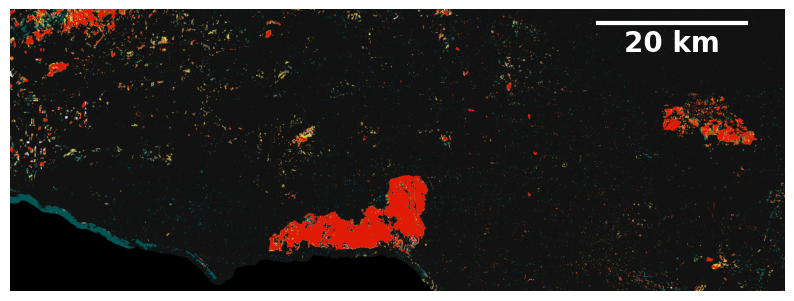

In [68]:
cmap, norm = get_dist_s1_mpl_cmap()
fig, ax = plt.subplots(figsize=(10, 10))
show(X, cmap=cmap, norm=norm, ax=ax, transform=p['transform'])
add_scalebar(ax, p, width_proportion=0.25, position='upper right', fontsize=20)
ax.axis('off')


In [69]:
png_dir = Path('pngs')
event_png_dir = png_dir / KEY
event_png_dir.mkdir(exist_ok=True, parents=True)

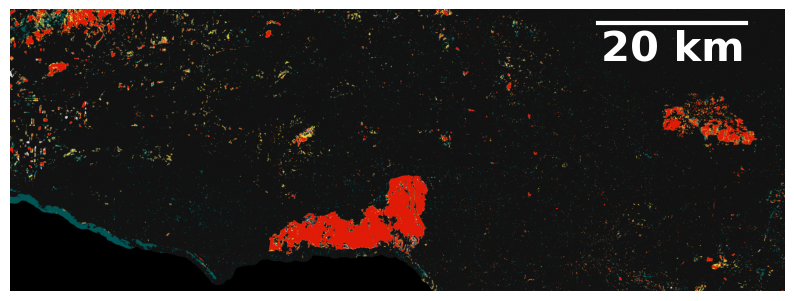

In [70]:
cmap, norm = get_dist_s1_mpl_cmap()
fig, ax = plt.subplots(figsize=(10, 10))
show(X, cmap=cmap, norm=norm, ax=ax, transform=p['transform'])
add_scalebar(ax, p, width_proportion=0.25, position='upper right', fontsize=30)
ax.axis('off')
fig.savefig(event_png_dir / f'{KEY}_dist_s1_status.png', dpi=500, bbox_inches='tight', pad_inches=0)


In [71]:
START_TIME = product_ts[INDEX] - pd.Timedelta(days=3)
STOP_TIME = product_ts[INDEX] + pd.Timedelta(days=3)
START_TIME, STOP_TIME


(Timestamp('2025-02-28 14:00:56+0000', tz='UTC'),
 Timestamp('2025-03-06 14:00:56+0000', tz='UTC'))

In [72]:
df_mgrs = get_mgrs_table()
df_mgrs.head()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
1,01FBF,32701,"MULTIPOLYGON(((199980 4600000,199980 4490200,3...","MULTIPOLYGON (((-179.58653 -48.72398, -179.638..."
2,01GBH,32701,"MULTIPOLYGON(((199980 4800040,199980 4690240,3...","MULTIPOLYGON (((-179.49865 -46.9259, -179.5458..."
3,01GDM,32701,"MULTIPOLYGON(((399960 5200000,399960 5090200,5...","POLYGON ((-178.23431 -43.34619, -178.25485 -44..."
4,01GEL,32701,"MULTIPOLYGON(((499980 5100040,499980 4990240,6...","POLYGON ((-177.00025 -44.25288, -177.00025 -45..."


In [73]:
def get_opera_id(query_item) -> str:
    return dict(query_item.__dict__['render_dict'])['meta']['native-id']

@retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, max=10))
def query_dist_hls_cmr_for_status_links(mgrs_tile_id: str, start_time=str(START_TIME.date()), stop_time=str(STOP_TIME.date())):
    collection_short_name = 'OPERA_L3_DIST-ALERT-HLS_V1'
    mgrs_bounds = tuple(df_mgrs[df_mgrs.mgrs_tile_id == mgrs_tile_id].total_bounds)
    mgrs_bounds = tuple(float(x) for x in mgrs_bounds)
    datasets_found = earthaccess.search_data(
        short_name=collection_short_name,
        temporal=(start_time, stop_time),
        cloud_hosted=True,
        bounding_box=mgrs_bounds
    )
    datasets_found = [d for d in datasets_found if mgrs_tile_id in get_opera_id(d)]
    links_status = [link for r in datasets_found for link in r.data_links() if 'DIST-STATUS.tif' in link.split('/')[-1]]
    links_veg_anom = [link for r in datasets_found for link in r.data_links() if 'VEG-ANOM.tif' in link.split('/')[-1]]
    links = links_status + links_veg_anom
    return links
    
def get_status_links_formatted_output(mgrs_tile_id: str) -> dict:
    links = query_dist_hls_cmr_for_status_links(mgrs_tile_id)
    out = {'mgrs_tile_id': mgrs_tile_id, 'links': links}
    return out

def get_opera_id_from_link(link: str) -> str:
    opera_id_and_layer = link.split('/')[-1]
    opera_id = '_'.join(opera_id_and_layer.split('_')[:-1])
    return opera_id

def get_processing_time_from_link(link: str) -> pd.Timestamp:
    opera_id_and_layer = link.split('/')[-1]
    processing_time = pd.Timestamp(opera_id_and_layer.split('_')[5])
    return processing_time

In [74]:
data = get_status_links_formatted_output(mgrs_tile_id)
data

{'mgrs_tile_id': '11SLT',
 'links': ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1_VEG-DIST-STATUS.tif',
  'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1_GEN-DIST-STATUS.tif',
  'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250302T183422Z_20250304T020740Z_L8_30_v1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250302T183422Z_20250304T020740Z_L8_30_v1_VEG-DIST-STATUS.tif',
  'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250302T183422Z_20250304T020740Z_L8_30_v1/OPERA_L3_

In [75]:
dist_hls_dir = Path('dist-hls')
dist_hls_dir.mkdir(exist_ok=True, parents=True)

In [76]:

@retry(stop=stop_after_attempt(4), wait=wait_exponential(multiplier=1, min=4, max=10))
def download_one(hls_link: str, dst_dir: Path) -> str:
    opera_id = get_opera_id_from_link(hls_link)
    out_dir = dst_dir / opera_id
    out_dir.mkdir(exist_ok=True, parents=True)
    r = earthaccess.download(hls_link, out_dir, pqdm_kwargs={'disable': True})
    return r

def download_data_dist_hls_data(data_dict: dict) -> str:
    links = data_dict['links']
    dist_hls_dir = Path('dist-hls')
    out_dir = dist_hls_dir / KEY_EVENT / mgrs_tile_id
     
    if links:
        links = sorted(links, key=get_processing_time_from_link)
        download_one_partial = partial(download_one, dst_dir=out_dir)
        with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
            out = list(tqdm(executor.map(download_one_partial, links), total=len(links), disable=True))
        return out
    else:
        return []

In [77]:
download_data_dist_hls_data(data)

[[PosixPath('dist-hls/los_angeles_fires_2025/11SLT/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1_VEG-DIST-STATUS.tif')],
 [PosixPath('dist-hls/los_angeles_fires_2025/11SLT/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1_GEN-DIST-STATUS.tif')],
 [PosixPath('dist-hls/los_angeles_fires_2025/11SLT/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250301T184219Z_20250303T042153Z_S2B_30_v1_VEG-ANOM.tif')],
 [PosixPath('dist-hls/los_angeles_fires_2025/11SLT/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250302T183422Z_20250304T020740Z_L8_30_v1/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250302T183422Z_20250304T020740Z_L8_30_v1_VEG-DIST-STATUS.tif')],
 [PosixPath('dist-hls/los_angeles_fires_2025/11SLT/OPERA_L3_DIST-ALERT-HLS_T11SLT_20250302T183422Z_20250304T0

In [78]:
event_hls_dir = Path(f'dist-hls/{KEY_EVENT}/{mgrs_tile_id}')
event_hls_dir.exists(), event_hls_dir


(True, PosixPath('dist-hls/los_angeles_fires_2025/11SLT'))

In [87]:
last_hls_dir = sorted(event_hls_dir.glob('*/'))[-1]
last_hls_dir.exists(), last_hls_dir

veg_status_hls_path = list(last_hls_dir.glob('**/*VEG-DIST-STATUS.tif'))[0]
gen_status_hls_path = list(last_hls_dir.glob('**/*GEN-DIST-STATUS.tif'))[0]

In [88]:
X_veg, p_veg = read_raster_from_window(veg_status_hls_path, bounds)
X_gen, p_gen = read_raster_from_window(gen_status_hls_path, bounds)
X_veg = X_veg[0, ...]
X_gen = X_gen[0, ...]




/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/dem_stitcher/rio_window.py:144: RuntimeWarning: Requesting extent beyond raster bounds of [300000.0, 3690240.0, 409800.0, 3800040.0]. Shrinking bounds in raster crs to (305036.44865980494, 3761931.1816153917, 409800.0, 3800040.0).
  warn(
/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/dem_stitcher/rio_window.py:144: RuntimeWarning: Requesting extent beyond raster bounds of [300000.0, 3690240.0, 409800.0, 3800040.0]. Shrinking bounds in raster crs to (305036.44865980494, 3761931.1816153917, 409800.0, 3800040.0).
  warn(


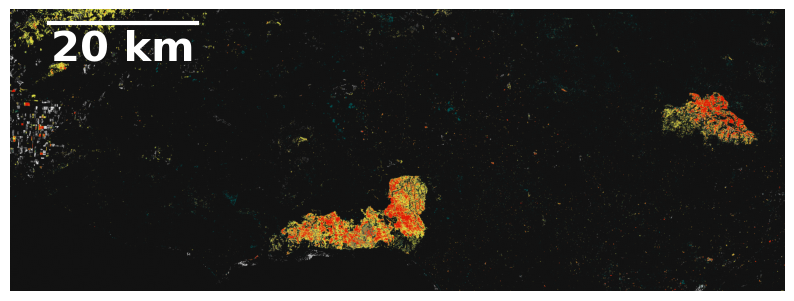

In [89]:
cmap, norm = get_dist_s1_mpl_cmap()
fig, ax = plt.subplots(figsize=(10, 10))
show(X_gen, cmap=cmap, norm=norm, ax=ax, transform=p['transform'])
add_scalebar(ax, p, width_proportion=0.25, position='upper left', fontsize=30)
ax.axis('off')
fig.savefig(event_png_dir / f'{KEY}_dist_hls_veg_stuats.png', dpi=500, bbox_inches='tight', pad_inches=0)


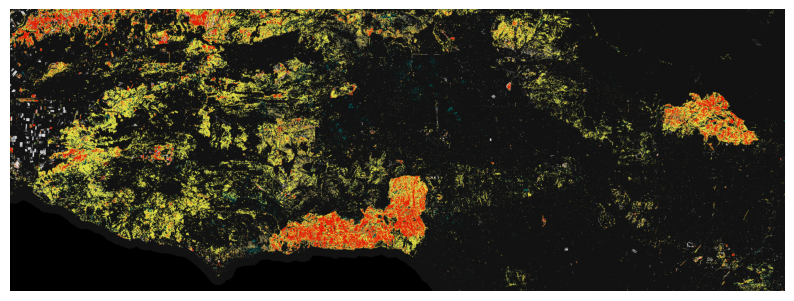

In [91]:
cmap, norm = get_dist_s1_mpl_cmap()
fig, ax = plt.subplots(figsize=(10, 10))
show(X_veg, cmap=cmap, norm=norm, ax=ax, transform=p['transform'])
#add_scalebar(ax, p, width_proportion=0.25, position='upper left', fontsize=30)
ax.axis('off')
fig.savefig(event_png_dir / f'{KEY}_dist_hls_veg_stuats.png', dpi=500, bbox_inches='tight', pad_inches=0)
